# Parabola branch: II and pooled R² before and after Σ⁻¹ normalization

This notebook adapts `gaussian_ols_svd_asymmetry.ipynb` to the synthetic
geometry in `glielmo_example.ipynb`. The source is one coordinate on a
non-negative parabola branch. The target contains the squared coordinate and
one independent, orthogonal direction that cannot be recovered from the source.

The shared module performs the complete analysis:

1. directional Information Imbalance (II) on the original spaces;
2. reciprocal full-data OLS and pooled R²;
3. the Σ⁻¹ SVD normalization of both fitted maps; and
4. II and pooled R² on the transformed spaces.

In [1]:
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml

# Locate config.yaml whether Jupyter starts in the project root or scripts folder.
cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in [cwd, *cwd.parents] if (path / "config.yaml").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate config.yaml from the current directory.")
# end if PROJECT_ROOT is None

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    project_config = yaml.safe_load(f)
paths = project_config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])

from II_analyses.asymmetry_pipeline import (
    generate_parabola_branch,
    run_asymmetry_pipeline,
    summarize_asymmetry_pipeline,
)

plt.rcParams.update(
    {"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False}
)

In [2]:
@dataclass
class Cfg:
    n_samples: int = 800
    latent_min: float = 0.0
    latent_max: float = 1.0
    orthogonal_noise_scale: float = 0.25
    seed: int = 20260812
    source_RDM_metric: str = "euclidean"
    target_RDM_metric: str = "euclidean"
    k: int = 5
    singular_value_rtol: float | None = None
    scatter_size: float = 10.0
    scatter_alpha: float = 0.55
# EOC


cfg = Cfg()
cfg

Cfg(n_samples=800, latent_min=0.0, latent_max=1.0, orthogonal_noise_scale=0.25, seed=20260812, source_RDM_metric='euclidean', target_RDM_metric='euclidean', k=5, singular_value_rtol=None, scatter_size=10.0, scatter_alpha=0.55)

## Generate the matched spaces

`X[:, 0]` parameterizes only one branch because it is non-negative. The first
target coordinate is `X²`; the second is independent Gaussian noise. Thus the
second target axis is geometrically orthogonal and statistically non-recoverable
from `X`.

X shape: (800, 1); Y shape: (800, 2)
corr(X, Y parabola coordinate): 0.9679
corr(X, Y orthogonal coordinate): -0.0202


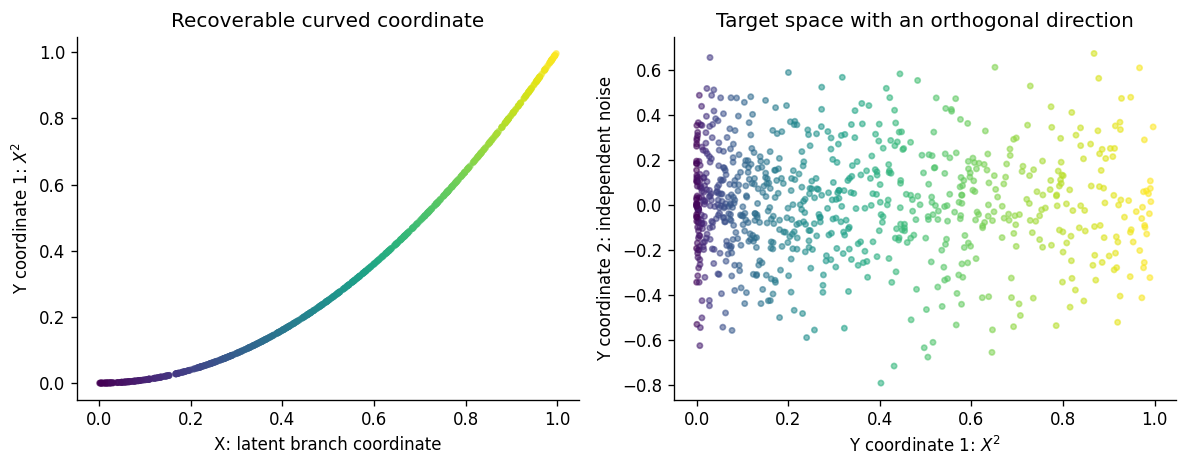

In [3]:
X, Y = generate_parabola_branch(
    n_samples=cfg.n_samples,
    latent_min=cfg.latent_min,
    latent_max=cfg.latent_max,
    orthogonal_noise_scale=cfg.orthogonal_noise_scale,
    seed=cfg.seed,
)

print(f"X shape: {X.shape}; Y shape: {Y.shape}")
print(f"corr(X, Y parabola coordinate): {np.corrcoef(X[:, 0], Y[:, 0])[0, 1]:.4f}")
print(f"corr(X, Y orthogonal coordinate): {np.corrcoef(X[:, 0], Y[:, 1])[0, 1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(
    X[:, 0], Y[:, 0], c=X[:, 0], cmap="viridis",
    s=cfg.scatter_size, alpha=cfg.scatter_alpha,
)
axes[0].set(
    xlabel="X: latent branch coordinate",
    ylabel=r"Y coordinate 1: $X^2$",
    title="Recoverable curved coordinate",
)
axes[1].scatter(
    Y[:, 0], Y[:, 1], c=X[:, 0], cmap="viridis",
    s=cfg.scatter_size, alpha=cfg.scatter_alpha,
)
axes[1].set(
    xlabel=r"Y coordinate 1: $X^2$",
    ylabel="Y coordinate 2: independent noise",
    title="Target space with an orthogonal direction",
)
fig.tight_layout()
plt.show()

## Run the original and Σ⁻¹-normalized analyses

The regression coefficient follows scikit-learn's convention
(W=U\Sigma V^\top), with outputs in rows. The shared helper forms
(W^\top U\Sigma^{-1}U^\top=V I_r U^\top): nonzero singular gains become one,
while numerical null directions stay zero.

In [4]:
pipeline = run_asymmetry_pipeline(
    X,
    Y,
    source_metric=cfg.source_RDM_metric,
    target_metric=cfg.target_RDM_metric,
    k=cfg.k,
    relative_tolerance=cfg.singular_value_rtol,
)
summary = summarize_asymmetry_pipeline(pipeline, "X", "Y")
display(summary.style.format({"pooled R2": "{:.6f}", "II": "{:.6f}"}))

print("X -> Y singular values:", np.round(pipeline["source_svd"]["singular_values"], 6))
print("X -> Y Sigma^-1:\n", np.round(pipeline["source_svd"]["sigma_inverse"], 6))
print("Y -> X singular values:", np.round(pipeline["target_svd"]["singular_values"], 6))
print("Y -> X Sigma^-1:\n", np.round(pipeline["target_svd"]["sigma_inverse"], 6))
print(
    "Transformed shapes: "
    f"X_tilde={pipeline['transformed_source'].shape}, "
    f"Y_tilde={pipeline['transformed_target'].shape}"
)

,stage,direction,R2 per output,pooled R2,II
0,original,X -> Y,"[0.936824, 0.000408]",0.566303,0.503099
1,original,Y -> X,[0.936838],0.936838,0.095827
2,Sigma^-1 normalized,X -> Y,[0.936838],0.936838,0.010816
3,Sigma^-1 normalized,Y -> X,"[0.936838, 0.936838]",0.936838,0.010806


X -> Y singular values: [1.009969]
X -> Y Sigma^-1:
 [[0.99013]]
Y -> X singular values: [0.927659]
Y -> X Sigma^-1:
 [[1.077982]]
Transformed shapes: X_tilde=(800, 2), Y_tilde=(800, 1)


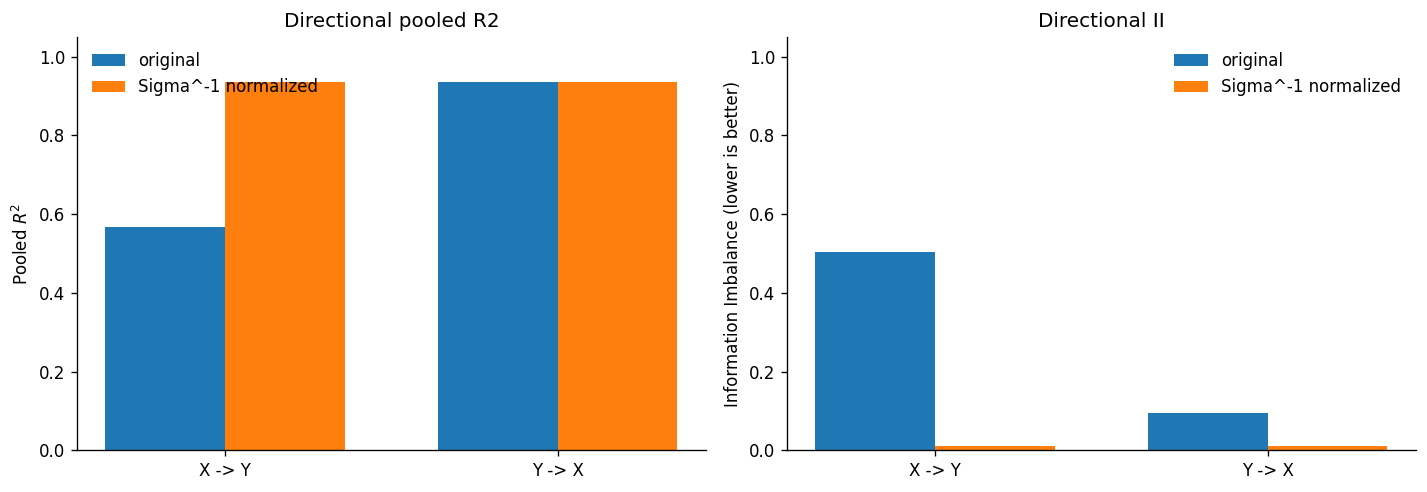

In [5]:
metric_specs = (
    ("pooled R2", r"Pooled $R^2$", (0, 1.05)),
    ("II", "Information Imbalance (lower is better)", (0, 1.05)),
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

for ax, (metric, ylabel, ylim) in zip(axes, metric_specs):
    x_positions = np.arange(2)
    width = 0.36
    for offset, (stage, stage_rows) in zip(
        (-width / 2, width / 2), summary.groupby("stage", sort=False)
    ):
        ax.bar(
            x_positions + offset,
            stage_rows[metric],
            width,
            label=stage,
        )
    # end for offset, (stage, stage_rows)
    ax.set_xticks(x_positions, ["X -> Y", "Y -> X"])
    ax.set(ylabel=ylabel, ylim=ylim, title=f"Directional {metric}")
    ax.legend(frameon=False)
# end for ax, (metric, ylabel, ylim)

fig.tight_layout()
plt.show()

## Reading the result

Pooled R² evaluates a linear prediction and therefore penalizes both the curved
relationship and the target-only coordinate. II instead compares neighborhood
ranks and can capture the monotonic geometry of the parabola branch. The two
quantities answer different questions; Σ⁻¹ normalization changes gains and
active subspaces, but it cannot manufacture information about the independent
target coordinate.